In [1]:
# ── CELL 1 ── Imports & Seed
import os, time, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, f1_score, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score, roc_auc_score,
    confusion_matrix, classification_report
)
import joblib

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

CLASS_NAMES  = ["BIODEGRADABLE", "CARDBOARD", "GLASS", "METAL", "PAPER", "PLASTIC"]
CLASS_COLORS = ["#4CAF50", "#8D6E63", "#64B5F6", "#B0BEC5", "#FFEE58", "#EF9A9A"]

print("Imports OK — E12 Three-Way Mega Hybrid")



Imports OK — E12 Three-Way Mega Hybrid


In [2]:
# ── CELL 2 ── Resolve repo root
import sys

# Works both in Colab (Drive mount) and locally
_candidate_local  = os.path.expanduser("~/Desktop/CV-Project")
_candidate_colab  = "/content/drive/MyDrive/CV/repo"

if os.path.isdir(_candidate_colab):
    REPO_ROOT = _candidate_colab
elif os.path.isdir(_candidate_local):
    REPO_ROOT = _candidate_local
else:
    REPO_ROOT = os.getcwd()          # fallback: notebook's CWD

FEAT_DIR   = os.path.join(REPO_ROOT, "data", "processed", "features")
MODELS_DIR = os.path.join(REPO_ROOT, "models")
RESULTS_DIR= os.path.join(REPO_ROOT, "results", "metrics")
FIGS_DIR   = os.path.join(REPO_ROOT, "figures", "fusion")

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGS_DIR,    exist_ok=True)

print(f"REPO_ROOT  : {REPO_ROOT}")
print(f"FEAT_DIR   : {FEAT_DIR}")



REPO_ROOT  : /Users/nadaashraf/Desktop/CV-Project
FEAT_DIR   : /Users/nadaashraf/Desktop/CV-Project/data/processed/features


In [3]:
# ── CELL 3 ── Load all three feature modalities
print("Loading feature arrays …")

# YOLO SPPF features (256-dim)
yolo_tr_X = np.load(os.path.join(FEAT_DIR, "yolo_train_X.npy"))
yolo_va_X = np.load(os.path.join(FEAT_DIR, "yolo_val_X.npy"))
yolo_te_X = np.load(os.path.join(FEAT_DIR, "yolo_test_X.npy"))
yolo_tr_y = np.load(os.path.join(FEAT_DIR, "yolo_train_y.npy"))
yolo_va_y = np.load(os.path.join(FEAT_DIR, "yolo_val_y.npy"))
yolo_te_y = np.load(os.path.join(FEAT_DIR, "yolo_test_y.npy"))

# EfficientNetB0 deep features (1280-dim)
deep_tr_X = np.load(os.path.join(FEAT_DIR, "deep_train_X.npy"))
deep_va_X = np.load(os.path.join(FEAT_DIR, "deep_val_X.npy"))
deep_te_X = np.load(os.path.join(FEAT_DIR, "deep_test_X.npy"))

# Classical hand-crafted features (252-dim) — use clean (no augmentation)
clas_tr_X = np.load(os.path.join(FEAT_DIR, "classical_train_clean_X.npy"))
clas_va_X = np.load(os.path.join(FEAT_DIR, "classical_val_X.npy"))
clas_te_X = np.load(os.path.join(FEAT_DIR, "classical_test_X.npy"))

# Labels from classical (all three are row-aligned)
y_train = np.load(os.path.join(FEAT_DIR, "classical_train_clean_y.npy"))
y_val   = np.load(os.path.join(FEAT_DIR, "classical_val_y.npy"))
y_test  = np.load(os.path.join(FEAT_DIR, "classical_test_y.npy"))

print(f"YOLO  train: {yolo_tr_X.shape}  val: {yolo_va_X.shape}  test: {yolo_te_X.shape}")
print(f"Deep  train: {deep_tr_X.shape}  val: {deep_va_X.shape}  test: {deep_te_X.shape}")
print(f"Class train: {clas_tr_X.shape}  val: {clas_va_X.shape}  test: {clas_te_X.shape}")
print(f"Labels train: {y_train.shape}  val: {y_val.shape}  test: {y_test.shape}")

# Sanity: all splits must be row-aligned
assert yolo_tr_X.shape[0] == deep_tr_X.shape[0] == clas_tr_X.shape[0] == y_train.shape[0], \
    "Train arrays not row-aligned!"
assert yolo_va_X.shape[0] == deep_va_X.shape[0] == clas_va_X.shape[0] == y_val.shape[0], \
    "Val arrays not row-aligned!"
assert yolo_te_X.shape[0] == deep_te_X.shape[0] == clas_te_X.shape[0] == y_test.shape[0], \
    "Test arrays not row-aligned!"

print("Row alignment OK ✓")


Loading feature arrays …
YOLO  train: (45177, 256)  val: (9935, 256)  test: (10553, 256)
Deep  train: (45177, 1280)  val: (9935, 1280)  test: (10553, 1280)
Class train: (45177, 252)  val: (9935, 252)  test: (10553, 252)
Labels train: (45177,)  val: (9935,)  test: (10553,)
Row alignment OK ✓


In [4]:
# ── CELL 4 ── Scale each modality independently then concatenate
print("Scaling modalities …")

scaler_yolo = StandardScaler()
scaler_deep = StandardScaler()
scaler_clas = StandardScaler()

yolo_tr_s = scaler_yolo.fit_transform(yolo_tr_X)
yolo_va_s = scaler_yolo.transform(yolo_va_X)
yolo_te_s = scaler_yolo.transform(yolo_te_X)

deep_tr_s = scaler_deep.fit_transform(deep_tr_X)
deep_va_s = scaler_deep.transform(deep_va_X)
deep_te_s = scaler_deep.transform(deep_te_X)

clas_tr_s = scaler_clas.fit_transform(clas_tr_X)
clas_va_s = scaler_clas.transform(clas_va_X)
clas_te_s = scaler_clas.transform(clas_te_X)

# Raw concatenation: 256 + 1280 + 252 = 1788-dim
X_train_raw = np.hstack([yolo_tr_s, deep_tr_s, clas_tr_s])
X_val_raw   = np.hstack([yolo_va_s, deep_va_s, clas_va_s])
X_test_raw  = np.hstack([yolo_te_s, deep_te_s, clas_te_s])

print(f"Raw fused dim : {X_train_raw.shape[1]}  (YOLO 256 + Deep 1280 + Classical 252)")
print(f"Train shape   : {X_train_raw.shape}")


Scaling modalities …
Raw fused dim : 1788  (YOLO 256 + Deep 1280 + Classical 252)
Train shape   : (45177, 1788)


In [5]:
# ── CELL 5 ── PCA compression (95% variance, same recipe as E5)
print("Fitting PCA (95% variance) …")
t0 = time.time()

pca = PCA(n_components=0.95, svd_solver="full", random_state=SEED)
X_train_pca = pca.fit_transform(X_train_raw)
X_val_pca   = pca.transform(X_val_raw)
X_test_pca  = pca.transform(X_test_raw)

pca_time = time.time() - t0
n_components = pca.n_components_
var_retained  = float(pca.explained_variance_ratio_.sum())

print(f"PCA done in {pca_time:.1f}s")
print(f"  Components retained : {n_components}  (from 1788)")
print(f"  Variance retained   : {var_retained*100:.2f}%")
print(f"  Train PCA shape     : {X_train_pca.shape}")


Fitting PCA (95% variance) …
PCA done in 2.6s
  Components retained : 1088  (from 1788)
  Variance retained   : 95.01%
  Train PCA shape     : (45177, 1088)


In [6]:
# ── CELL 6 ── Train SVM (RBF, C=10, same as E5)
print("\nTraining SVM(RBF, C=10, probability=True) …")
t0 = time.time()

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    probability=True,
    class_weight="balanced",
    random_state=SEED,
    max_iter=5000,
)
svm.fit(X_train_pca, y_train)

fit_time = time.time() - t0
print(f"SVM training complete in {fit_time:.1f}s")

# Validation quick-check
val_pred     = svm.predict(X_val_pca)
val_macro_f1 = f1_score(y_val, val_pred, average="macro")
val_acc      = accuracy_score(y_val, val_pred)
print(f"Val  accuracy  : {val_acc:.4f}")
print(f"Val  macro-F1  : {val_macro_f1:.4f}")




Training SVM(RBF, C=10, probability=True) …
SVM training complete in 1124.7s
Val  accuracy  : 0.8778
Val  macro-F1  : 0.7970


In [7]:
# ── CELL 7 ── Full test evaluation
print("\nEvaluating on test set …")
t_infer_start = time.time()
y_pred  = svm.predict(X_test_pca)
y_proba = svm.predict_proba(X_test_pca)
infer_time = (time.time() - t_infer_start) / len(y_test) * 1000  # ms/sample

acc       = accuracy_score(y_test, y_pred)
macro_f1  = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
bal_acc   = balanced_accuracy_score(y_test, y_pred)
mcc       = matthews_corrcoef(y_test, y_pred)
kappa     = cohen_kappa_score(y_test, y_pred)
auc_macro = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
top2_mask = np.argsort(y_proba, axis=1)[:, -2:]
top2_acc  = np.mean([y_test[i] in top2_mask[i] for i in range(len(y_test))])

per_class_f1   = f1_score(y_test, y_pred, average=None)
per_class_prec = __import__("sklearn.metrics", fromlist=["precision_score"]).precision_score(
    y_test, y_pred, average=None, zero_division=0)
per_class_rec  = __import__("sklearn.metrics", fromlist=["recall_score"]).recall_score(
    y_test, y_pred, average=None, zero_division=0)
per_class_auc  = roc_auc_score(y_test, y_proba, multi_class="ovr", average=None)

overfitting_gap = val_macro_f1 - macro_f1

print(f"\n{'='*55}")
print(f"  E12 Three-Way Mega Hybrid — Test Results")
print(f"{'='*55}")
print(f"  Accuracy          : {acc:.4f}")
print(f"  Macro-F1          : {macro_f1:.4f}  ← primary metric")
print(f"  Weighted-F1       : {weighted_f1:.4f}")
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  MCC               : {mcc:.4f}")
print(f"  Cohen Kappa       : {kappa:.4f}")
print(f"  AUC-ROC (macro)   : {auc_macro:.4f}")
print(f"  Top-2 Accuracy    : {top2_acc:.4f}")
print(f"  Inference (ms/crop): {infer_time:.4f}")
print(f"  Overfitting gap   : {overfitting_gap:+.4f}  (val-test)")
print(f"{'='*55}")
print("\nPer-class F1:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name:<18}: F1={per_class_f1[i]:.4f}  "
          f"P={per_class_prec[i]:.4f}  R={per_class_rec[i]:.4f}  AUC={per_class_auc[i]:.4f}")




Evaluating on test set …

  E12 Three-Way Mega Hybrid — Test Results
  Accuracy          : 0.8729
  Macro-F1          : 0.8130  ← primary metric
  Weighted-F1       : 0.8676
  Balanced Accuracy : 0.7863
  MCC               : 0.7998
  Cohen Kappa       : 0.7954
  AUC-ROC (macro)   : 0.9658
  Top-2 Accuracy    : 0.9491
  Inference (ms/crop): 23.7081
  Overfitting gap   : -0.0161  (val-test)

Per-class F1:
  BIODEGRADABLE     : F1=0.9352  P=0.8895  R=0.9858  AUC=0.9682
  CARDBOARD         : F1=0.9016  P=0.8913  R=0.9122  AUC=0.9953
  GLASS             : F1=0.7692  P=0.9134  R=0.6643  AUC=0.9292
  METAL             : F1=0.7821  P=0.7922  R=0.7722  AUC=0.9755
  PAPER             : F1=0.7485  P=0.8607  R=0.6623  AUC=0.9671
  PLASTIC           : F1=0.7416  P=0.7635  R=0.7209  AUC=0.9592


In [8]:
# ── CELL 8 ── Compare against all previous experiments
print("\nHead-to-head comparison (classification track, Macro-F1):")
prev = {
    "E2 Classical+RF":          0.6476,
    "E3 Deep+SVM":              0.7848,
    "E4 Early Fusion Raw":      0.6960,
    "E5 Early Fusion PCA (🏆)": 0.8071,
    "E6 Early Fusion AE":       0.7705,
    "E7 Feature Selection":     0.7081,
    "E8 Late Avg Voting":       None,   # fill from Bayo's results
    "E9 Late Weighted Voting":  None,
    "E10 Attention Fusion":     None,
    "E11 YOLO+Classical":       0.7345,
    "E12 Three-Way (THIS)":     macro_f1,
}

baseline_best = 0.8071  # E5
print(f"\n{'Experiment':<30} {'Macro-F1':>10}  {'vs E5':>8}")
print("-" * 52)
for exp, f1 in prev.items():
    if f1 is None:
        print(f"  {exp:<28}  {'N/A':>10}")
        continue
    delta = f1 - baseline_best
    marker = " ← NEW BEST" if f1 > baseline_best and "THIS" in exp else ""
    print(f"  {exp:<28}  {f1:>10.4f}  {delta:>+8.4f}{marker}")




Head-to-head comparison (classification track, Macro-F1):

Experiment                       Macro-F1     vs E5
----------------------------------------------------
  E2 Classical+RF                   0.6476   -0.1595
  E3 Deep+SVM                       0.7848   -0.0223
  E4 Early Fusion Raw               0.6960   -0.1111
  E5 Early Fusion PCA (🏆)           0.8071   +0.0000
  E6 Early Fusion AE                0.7705   -0.0366
  E7 Feature Selection              0.7081   -0.0990
  E8 Late Avg Voting                   N/A
  E9 Late Weighted Voting              N/A
  E10 Attention Fusion                 N/A
  E11 YOLO+Classical                0.7345   -0.0726
  E12 Three-Way (THIS)              0.8130   +0.0059 ← NEW BEST


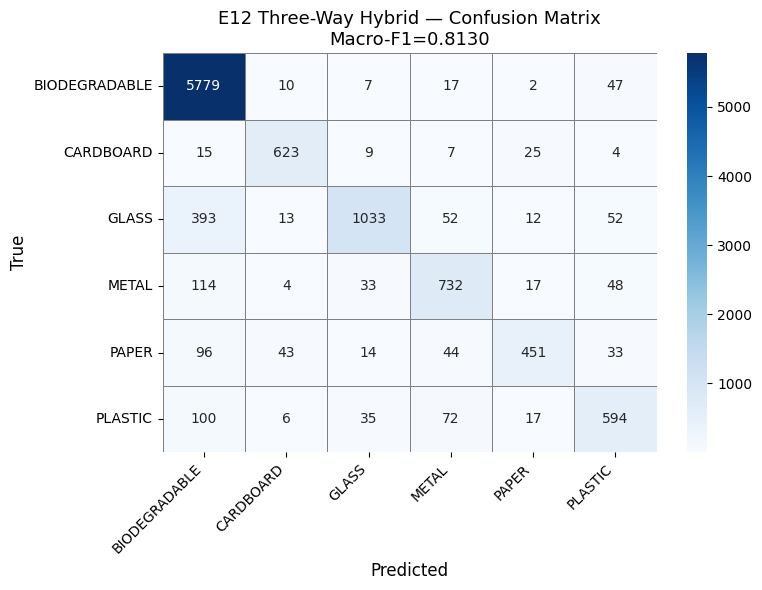

Saved: E12_confusion_matrix.png


In [9]:

# ── CELL 9 ── Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax,
    linewidths=0.5, linecolor="gray"
)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"E12 Three-Way Hybrid — Confusion Matrix\nMacro-F1={macro_f1:.4f}", fontsize=13)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E12_confusion_matrix.png"), dpi=150)
plt.show()
print("Saved: E12_confusion_matrix.png")


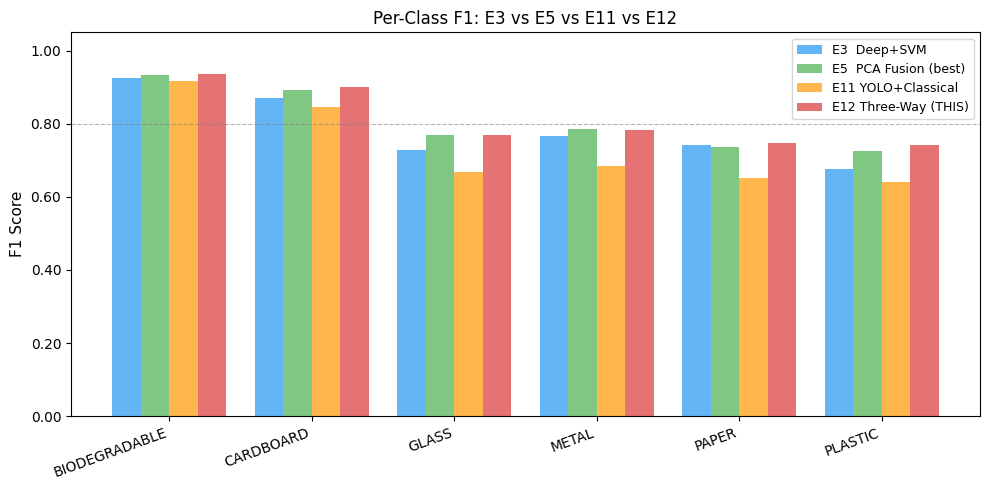

Saved: E12_vs_others_perclass_f1.png


In [10]:

# ── CELL 10 ── Per-class F1 bar chart vs E3/E5/E11
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(CLASS_NAMES))
width = 0.2

e3_f1  = [0.9249, 0.8706, 0.7294, 0.7654, 0.7419, 0.6767]
e5_f1  = [0.9340, 0.8934, 0.7681, 0.7848, 0.7373, 0.7253]
e11_f1 = [0.9181, 0.8455, 0.6677, 0.6842, 0.6523, 0.6393]
e12_f1 = list(per_class_f1)

bars_e3  = ax.bar(x - 1.5*width, e3_f1,  width, label="E3  Deep+SVM",        color="#64B5F6")
bars_e5  = ax.bar(x - 0.5*width, e5_f1,  width, label="E5  PCA Fusion (best)", color="#81C784")
bars_e11 = ax.bar(x + 0.5*width, e11_f1, width, label="E11 YOLO+Classical",   color="#FFB74D")
bars_e12 = ax.bar(x + 1.5*width, e12_f1, width, label="E12 Three-Way (THIS)", color="#E57373")

ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=20, ha="right", fontsize=10)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1: E3 vs E5 vs E11 vs E12", fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.axhline(0.8, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E12_vs_others_perclass_f1.png"), dpi=150)
plt.show()
print("Saved: E12_vs_others_perclass_f1.png")



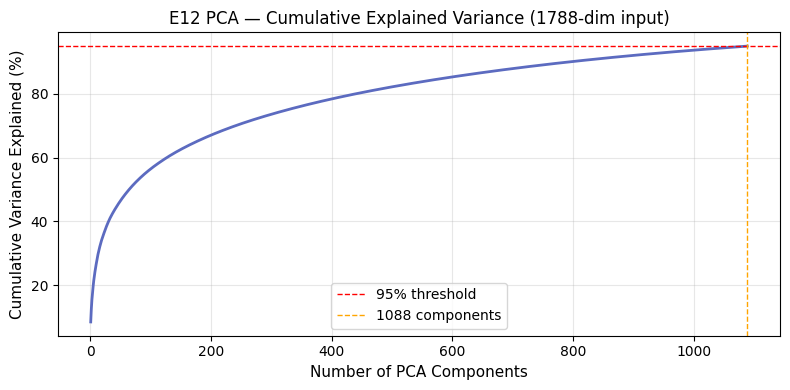

Saved: E12_pca_variance_curve.png


In [11]:

# ── CELL 11 ── PCA explained variance curve
fig, ax = plt.subplots(figsize=(8, 4))
cumvar = np.cumsum(pca.explained_variance_ratio_)
ax.plot(range(1, len(cumvar)+1), cumvar * 100, color="#5C6BC0", linewidth=2)
ax.axhline(95, color="red", linestyle="--", linewidth=1, label="95% threshold")
ax.axvline(n_components, color="orange", linestyle="--", linewidth=1,
           label=f"{n_components} components")
ax.set_xlabel("Number of PCA Components", fontsize=11)
ax.set_ylabel("Cumulative Variance Explained (%)", fontsize=11)
ax.set_title("E12 PCA — Cumulative Explained Variance (1788-dim input)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, "E12_pca_variance_curve.png"), dpi=150)
plt.show()
print("Saved: E12_pca_variance_curve.png")


In [12]:

# ── CELL 12 ── Save models and scalers
model_path = os.path.join(MODELS_DIR, "e12_svm_model.pkl")
joblib.dump(svm, model_path)

scalers = {
    "scaler_yolo": scaler_yolo,
    "scaler_deep": scaler_deep,
    "scaler_clas": scaler_clas,
    "pca":         pca,
}
joblib.dump(scalers, os.path.join(MODELS_DIR, "e12_scalers_pca.pkl"))

model_size_mb = os.path.getsize(model_path) / 1e6

print(f"Saved SVM model : {model_path}  ({model_size_mb:.1f} MB)")
print(f"Saved scalers   : {os.path.join(MODELS_DIR, 'e12_scalers_pca.pkl')}")



Saved SVM model : /Users/nadaashraf/Desktop/CV-Project/models/e12_svm_model.pkl  (161.3 MB)
Saved scalers   : /Users/nadaashraf/Desktop/CV-Project/models/e12_scalers_pca.pkl


In [13]:

# ── CELL 13 ── Write results to classification_results.csv
from sklearn.metrics import precision_score, recall_score

results_csv = os.path.join(RESULTS_DIR, "classification_results.csv")

new_row = {
    "experiment":         "E12",
    "model":              "SVM_RBF_ThreeWay",
    "augmentation":       "",
    "timestamp":          datetime.now().strftime("%Y-%m-%d %H:%M"),
    "accuracy":           round(acc, 4),
    "macro_f1":           round(macro_f1, 4),
    "weighted_f1":        round(weighted_f1, 4),
    "balanced_accuracy":  round(bal_acc, 4),
    "mcc":                round(mcc, 4),
    "cohen_kappa":        round(kappa, 4),
    "auc_roc_macro":      round(auc_macro, 4),
    "top2_accuracy":      round(top2_acc, 4),
    "feature_dim":        n_components,
    "n_train_samples":    len(y_train),
    "inference_ms_per_crop": round(infer_time, 4),
    "extraction_ms_per_crop": "",
    "extraction_throughput_cps": "",
    "f1_BIODEGRADABLE":   round(per_class_f1[0], 4),
    "f1_CARDBOARD":       round(per_class_f1[1], 4),
    "f1_GLASS":           round(per_class_f1[2], 4),
    "f1_METAL":           round(per_class_f1[3], 4),
    "f1_PAPER":           round(per_class_f1[4], 4),
    "f1_PLASTIC":         round(per_class_f1[5], 4),
    "prec_BIODEGRADABLE": round(per_class_prec[0], 4),
    "prec_CARDBOARD":     round(per_class_prec[1], 4),
    "prec_GLASS":         round(per_class_prec[2], 4),
    "prec_METAL":         round(per_class_prec[3], 4),
    "prec_PAPER":         round(per_class_prec[4], 4),
    "prec_PLASTIC":       round(per_class_prec[5], 4),
    "rec_BIODEGRADABLE":  round(per_class_rec[0], 4),
    "rec_CARDBOARD":      round(per_class_rec[1], 4),
    "rec_GLASS":          round(per_class_rec[2], 4),
    "rec_METAL":          round(per_class_rec[3], 4),
    "rec_PAPER":          round(per_class_rec[4], 4),
    "rec_PLASTIC":        round(per_class_rec[5], 4),
    "val_accuracy":       round(val_acc, 4),
    "val_macro_f1":       round(val_macro_f1, 4),
    "auc_BIODEGRADABLE":  round(per_class_auc[0], 4),
    "auc_CARDBOARD":      round(per_class_auc[1], 4),
    "auc_GLASS":          round(per_class_auc[2], 4),
    "auc_METAL":          round(per_class_auc[3], 4),
    "auc_PAPER":          round(per_class_auc[4], 4),
    "auc_PLASTIC":        round(per_class_auc[5], 4),
    "overfitting_gap":    round(overfitting_gap, 4),
    "fit_time_s":         round(fit_time, 1),
    "classifier":         f"SVM(RBF,C=10)",
    "compression":        f"PCA_95pct",
    "original_dim":       1788.0,
    "pca_components":     n_components,
    "variance_retained":  round(var_retained, 4),
    "ae_epochs":          "",
    "classical_features_selected": "",
    "deep_features_selected":      "",
    "model_size_mb":      round(model_size_mb, 4),
}

if os.path.isfile(results_csv):
    df = pd.read_csv(results_csv)
    # Remove stale E12 row if re-running
    df = df[df["experiment"] != "E12"]
    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
else:
    df = pd.DataFrame([new_row])

df.to_csv(results_csv, index=False)
print(f"\nAppended E12 row → {results_csv}")
print(f"\nFinal summary:")
print(f"  Macro-F1 = {macro_f1:.4f}  |  Accuracy = {acc:.4f}  |  AUC = {auc_macro:.4f}")
print(f"  PCA: 1788 → {n_components} components ({var_retained*100:.1f}% variance)")
print(f"  SVM fit: {fit_time:.0f}s  |  Inference: {infer_time:.2f} ms/crop")
print(f"\nDone — E12 complete ✓")



Appended E12 row → /Users/nadaashraf/Desktop/CV-Project/results/metrics/classification_results.csv

Final summary:
  Macro-F1 = 0.8130  |  Accuracy = 0.8729  |  AUC = 0.9658
  PCA: 1788 → 1088 components (95.0% variance)
  SVM fit: 1125s  |  Inference: 23.71 ms/crop

Done — E12 complete ✓
